# Volume experiment — b-approximated polytope ratio

For each quantization bit-width $b$, plots:
$$\frac{\sum_{i} \text{vol}^b_i}{\sum_{i} \text{vol}^{\mathrm{correct}}_i}$$
where the sums run over all samples $i$ in the result files.
A ratio close to 1 means the quantized model preserves almost all the volume of the correct polytope.

## Setup

In [27]:
%load_ext autoreload
%autoreload 2

import json
import os
from pathlib import Path

import math
import numpy as np

import matplotlib.pyplot as plt

ROOT = Path(os.getcwd()).parent
print("Project root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: /Users/jeremiecabessa/Desktop/ROOT/Articles/Conference_Papers/2025_With_Jiri/code/ErrorVolumePolytopes


## Load results

In [28]:
RESULTS_DIR = ROOT / "results" / "volumes_mlp"  # change for the full run

files = sorted(RESULTS_DIR.glob("volumes_sample*.json"))
print(f"Found {len(files)} result files.")

records = []
for f in files:
    with open(f) as fh:
        records.append(json.load(fh))

# Show one record as a sanity check
records[999]

Found 1000 result files.


{'sample_idx': 999,
 'model_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/checkpoints/fashion_mlp_best.pth',
 'data_path': '/lustre/fswork/projects/rech/aik/uhr51mx/ErrorVolumePolytopes/data/fashionMNIST_correct_mlp.pt',
 'n_directions': 200,
 'n_directions_used': 200,
 'bits_grid': [4, 6, 8, 10, 12, 16],
 'width_correct': 39.79743132640023,
 'widths_both': {'4': 37.83848624644701,
  '6': 39.43458748598023,
  '8': 39.7204764759721,
  '10': 39.77738387715707,
  '12': 39.792698714261654,
  '16': 39.797125782947106}}

## Compute per-bits ratio

$$\text{ratio}(b) = \frac{\sum_{i} \text{vol}^b_i}{\sum_{i} \text{vol}^{\mathrm{correct}}_i}$$

In [32]:
# Collect all bit-widths from the first record (keys are strings in JSON)
bits_grid = sorted(int(b) for b in records[0]["widths_both"].keys())
print("Bits grid:", bits_grid)

# Count and filter NaN records
nan_correct = sum(1 for r in records if math.isnan(r["width_correct"]))
nan_bits    = {b: sum(1 for r in records if math.isnan(r["widths_both"][str(b)])) for b in bits_grid}
print(f"\nNaN in width_correct: {nan_correct}/{len(records)}")
for b in bits_grid:
    print(f"  NaN in bits={b:2d}: {nan_bits[b]}/{len(records)}")

# Keep only records where all values are finite
clean = [
    r for r in records
    if not math.isnan(r["width_correct"])
    and all(not math.isnan(r["widths_both"][str(b)]) for b in bits_grid)
]
print(f"\nClean records: {len(clean)}/{len(records)}")

sum_correct = sum(r["width_correct"] for r in clean)
ratios = {
    b: sum(r["widths_both"][str(b)] for r in clean) / sum_correct
    for b in bits_grid
}

print(f"\nSum of correct widths over {len(clean)} samples: {sum_correct:.4f}")
print("\nRatios:")
for b, ratio in ratios.items():
    print(f"  bits={b:2d}  ratio={ratio:.4f}  error={1-ratio:.6f}")

Bits grid: [4, 6, 8, 10, 12, 16]

NaN in width_correct: 6/1000
  NaN in bits= 4: 6/1000
  NaN in bits= 6: 6/1000
  NaN in bits= 8: 6/1000
  NaN in bits=10: 6/1000
  NaN in bits=12: 6/1000
  NaN in bits=16: 6/1000

Clean records: 994/1000

Sum of correct widths over 994 samples: 39567.5155

Ratios:
  bits= 4  ratio=0.9457  error=0.054299
  bits= 6  ratio=0.9859  error=0.014095
  bits= 8  ratio=0.9965  error=0.003509
  bits=10  ratio=0.9991  error=0.000924
  bits=12  ratio=0.9998  error=0.000199
  bits=16  ratio=1.0000  error=0.000014


## Plot

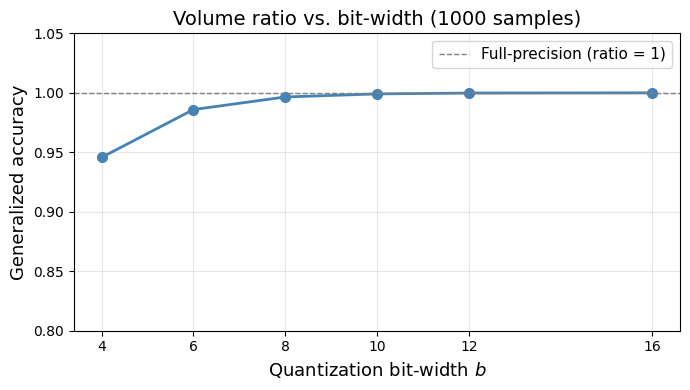

In [33]:
bits_arr  = np.array(bits_grid)
ratio_arr = np.array([ratios[b] for b in bits_grid])

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(bits_arr, ratio_arr, marker="o", linewidth=2, markersize=7, color="steelblue")
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Full-precision (ratio = 1)")

ax.set_xlabel("Quantization bit-width $b$", fontsize=13)
ax.set_ylabel(
    "Generalized accuracy",
    fontsize=13,
)
ax.set_title(
    f"Volume ratio vs. bit-width ({len(records)} samples)",
    fontsize=14,
)
ax.set_xticks(bits_arr)
ax.set_ylim(0.8, 1.05)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "volumes_ratio.pdf", bbox_inches="tight")
plt.show()